# 🔥 Đánh Giá Hiệu Năng FireGrounder V3 Trên Tập Ảnh `fire-samples`

Notebook này thực hiện kiểm thử và đánh giá độ chính xác toàn diện của mô hình **FireGrounder V3** (MobileNetV4 + FPN-lite Heatmap) trên tập ảnh thử nghiệm `fire-samples`.

### Bảng thông số đánh giá chuẩn theo `week6_v3_merged.ipynb`:
- **Chỉ số phân loại (Classification):** Precision, Recall, F1-Score, TP, FP, TN, FN.
- **Chỉ số định vị gốc lửa (Localization):** MAE (px), Median (px), P90 (px), PCK@10px, PCK@25px, % sai số $\le$ 5px.
- **Hiệu năng suy luận (Inference Speed):** Latency (ms/frame) và FPS trên GPU/CPU.
- **Phân tích ngưỡng (Threshold Sweep):** So sánh hiệu năng giữa các ngưỡng `0.05`, `0.10`, `0.20`, `0.50`.
- **Trực quan hóa (Visual Preview):** Lưới ảnh hiển thị điểm gốc lửa được mô hình V3 xác định.

In [1]:
# Cell 1: Thư viện & Thiết lập môi trường
import os, sys, json, time, math, random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt

# Thiết lập thiết bị chạy
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🚀 Thiết bị: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# Đường dẫn dự án
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'FireGrounder-V3-main' else NOTEBOOK_DIR

# Thêm thư mục chứa firegrounder_v3.py vào sys.path
for p in [NOTEBOOK_DIR, PROJECT_ROOT, NOTEBOOK_DIR / 'FireGrounder-V3-main']:
    if (p / 'firegrounder_v3.py').exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from firegrounder_v3 import FireGrounderV3, MEAN, STD, FIRE_THRESHOLD
print('✅ Đã nạp thành công module firegrounder_v3')

🚀 Thiết bị: cuda
   GPU: NVIDIA GeForce RTX 3060


✅ Đã nạp thành công module firegrounder_v3


In [2]:
# Cell 2: Tải mô hình FireGrounder V3 và checkpoint
CKPT_CANDIDATES = [
    NOTEBOOK_DIR / 'v3_outputs' / 'best_v3_fpn.pth',
    PROJECT_ROOT / 'FireGrounder-V3-main' / 'v3_outputs' / 'best_v3_fpn.pth',
    PROJECT_ROOT / 'v3_outputs' / 'best_v3_fpn.pth',
]

CKPT_PATH = None
for p in CKPT_CANDIDATES:
    if p.exists():
        CKPT_PATH = p
        break

assert CKPT_PATH is not None, f'❌ Không tìm thấy checkpoint best_v3_fpn.pth!'

model = FireGrounderV3(pretrained=False).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
model.load_state_dict(state_dict)
model.eval()

print(f'✅ Checkpoint đã tải: {CKPT_PATH}')
print(f'   Epoch: {ckpt.get("epoch", "?")}')
print(f'   Val Loss lúc train: {ckpt.get("val_loss", "?"):.6f}')

[FireGrounderV3] backbone=mobilenetv4_conv_medium channels=[48, 80, 960] heatmap=64 params=7,545,650


✅ Checkpoint đã tải: d:\2D Detection\FireGrounder-V3-main\FireGrounder-V3-main\v3_outputs\best_v3_fpn.pth
   Epoch: 19
   Val Loss lúc train: 0.040702


In [3]:
# Cell 3: Đọc dữ liệu tập 'fire-samples' và nạp nhãn
SAMPLE_DIRS = [
    PROJECT_ROOT / 'fire-samples',
    NOTEBOOK_DIR / 'fire-samples',
    NOTEBOOK_DIR.parent / 'fire-samples',
]

SAMPLES_DIR = None
for p in SAMPLE_DIRS:
    if p.exists() and p.is_dir():
        SAMPLES_DIR = p
        break
assert SAMPLES_DIR is not None, '❌ Không tìm thấy thư mục fire-samples!'

# 1. Đọc test_manifest.json (nhãn phân loại 415 ảnh)
manifest_path = SAMPLES_DIR / 'test_manifest.json'
assert manifest_path.exists(), f'❌ Không tìm thấy {manifest_path}'
with open(manifest_path, encoding='utf-8') as f:
    manifest_items = json.load(f)

# 2. Đọc coarse_manifest.json (tọa độ gốc lửa nếu có)
cm_candidates = [
    NOTEBOOK_DIR / 'coarse_manifest.json',
    PROJECT_ROOT / 'FireGrounder-V3-main' / 'coarse_manifest.json',
]
coarse_manifest = {}
for p in cm_candidates:
    if p.exists():
        with open(p, encoding='utf-8') as f:
            coarse_manifest = json.load(f)
        break

# Ánh xạ tọa độ từ coarse_manifest sang (category, filename)
cm_lookup = {}
for k, v in coarse_manifest.items():
    parts = k.replace('\\', '/').split('/')
    if len(parts) >= 2:
        cat = parts[-2]  # fire, default, smoke
        fname = parts[-1] # img_103.jpg
        cm_lookup[(cat, fname)] = v

# Tổng hợp danh sách mẫu kiểm thử
dataset_records = []
exts = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

for item in manifest_items:
    fname = item['file']
    img_path = SAMPLES_DIR / fname
    if not img_path.exists():
        continue
    
    raw_label = item.get('label', 'default')
    has_fire = 1.0 if raw_label == 'fire' else 0.0
    
    # Tìm tọa độ chuẩn nếu có trong coarse_manifest
    cat = 'default' if 'default' in fname else ('smoke' if 'smoke' in fname else 'fire')
    short_fname = fname.replace('dataset_test_default_', '').replace('dataset_test_smoke_', '').replace('dataset_test_', '')
    
    coord_gt = None
    if (cat, short_fname) in cm_lookup:
        c_info = cm_lookup[(cat, short_fname)]
        pt = c_info.get('point')
        sz = c_info.get('size', [224, 224])
        if pt is not None and len(pt) >= 2 and sz is not None and len(sz) >= 2 and sz[0] > 0 and sz[1] > 0:
            coord_gt = [float(pt[0]) / sz[0], float(pt[1]) / sz[1]]
    
    dataset_records.append({
        'path': img_path,
        'file': fname,
        'label': raw_label,
        'has_fire': has_fire,
        'coord_gt': coord_gt,
    })

n_fire = sum(1 for r in dataset_records if r['has_fire'] == 1.0)
n_smoke = sum(1 for r in dataset_records if r['label'] == 'smoke')
n_default = sum(1 for r in dataset_records if r['label'] == 'default')
n_coords = sum(1 for r in dataset_records if r['coord_gt'] is not None)

print(f'📂 Thư mục kiểm thử : {SAMPLES_DIR}')
print(f'📊 Tổng số ảnh mẫu  : {len(dataset_records)} ảnh')
print(f'   🔥 Có lửa (Fire) : {n_fire} ảnh')
print(f'   💨 Khói (Smoke)  : {n_smoke} ảnh (nhãn âm tính)')
print(f'   🌿 Nền (Default) : {n_default} ảnh (nhãn âm tính)')
print(f'   📍 Có GT tọa độ  : {n_coords} ảnh')

📂 Thư mục kiểm thử : d:\2D Detection\FireGrounder-V3-main\fire-samples
📊 Tổng số ảnh mẫu  : 415 ảnh
   🔥 Có lửa (Fire) : 184 ảnh
   💨 Khói (Smoke)  : 149 ảnh (nhãn âm tính)
   🌿 Nền (Default) : 82 ảnh (nhãn âm tính)
   📍 Có GT tọa độ  : 36 ảnh


In [4]:
# Cell 4: Chạy suy luận toàn bộ tập dữ liệu và trích xuất chỉ số
IMG_SIZE = 256

class FireSamplesDataset(Dataset):
    def __init__(self, records):
        self.records = records
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec['path']).convert('RGB')
        img_resized = TF.resize(img, [IMG_SIZE, IMG_SIZE])
        tensor = TF.normalize(TF.to_tensor(img_resized), MEAN, STD)
        return tensor, rec['has_fire'], idx

loader = DataLoader(FireSamplesDataset(dataset_records), batch_size=32, shuffle=False, num_workers=0)

# Đo latency suy luận
start_time = time.time()
all_preds = []
all_gts = []

with torch.no_grad():
    for tensors, gts, _ in loader:
        tensors = tensors.to(DEVICE)
        out = model(tensors)
        if isinstance(out, dict):
            out = out['pred']
        all_preds.append(out.cpu())
        all_gts.append(gts)

elapsed_time = time.time() - start_time
total_samples = len(dataset_records)
latency_ms = (elapsed_time / total_samples) * 1000.0
fps = total_samples / elapsed_time

preds_tensor = torch.cat(all_preds) # [N, 3] -> [p_fire, x_norm, y_norm]
gts_tensor = torch.cat(all_gts)     # [N]

print(f'⚡ Tốc độ suy luận: {latency_ms:.2f} ms/frame | {fps:.1f} FPS trên {DEVICE.type.upper()}')

⚡ Tốc độ suy luận: 15.85 ms/frame | 63.1 FPS trên CUDA


In [5]:
# Cell 5: BẢNG THÔNG SỐ ĐÁNH GIÁ (GIỐNG WEEK6_V3_MERGED.IPYNB)
def calculate_metrics(threshold: float = 0.05):
    p_fire = preds_tensor[:, 0]
    pred_label = (p_fire >= threshold).float()
    gt_label = (gts_tensor >= 0.5).float()
    
    tp = int(((pred_label == 1) & (gt_label == 1)).sum().item())
    fp = int(((pred_label == 1) & (gt_label == 0)).sum().item())
    fn = int(((pred_label == 0) & (gt_label == 1)).sum().item())
    tn = int(((pred_label == 0) & (gt_label == 0)).sum().item())
    
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    
    # Tính sai số định vị gốc lửa trên các mẫu có GT tọa độ
    coord_errors = []
    for i, rec in enumerate(dataset_records):
        if rec['has_fire'] == 1.0 and rec['coord_gt'] is not None and pred_label[i] == 1:
            pred_x, pred_y = preds_tensor[i, 1].item(), preds_tensor[i, 2].item()
            gt_x, gt_y = rec['coord_gt'][0], rec['coord_gt'][1]
            err_px = math.sqrt((pred_x - gt_x)**2 + (pred_y - gt_y)**2) * IMG_SIZE
            coord_errors.append(err_px)
    
    if coord_errors:
        err_arr = np.array(coord_errors)
        mae = float(np.mean(err_arr))
        median = float(np.median(err_arr))
        p90 = float(np.percentile(err_arr, 90))
        pck10 = float((err_arr <= 10.0).mean() * 100)
        pck25 = float((err_arr <= 25.0).mean() * 100)
        within5 = float((err_arr <= 5.0).mean() * 100)
    else:
        mae = median = p90 = pck10 = pck25 = within5 = float('nan')
        
    return {
        'threshold': threshold,
        'precision': precision, 'recall': recall, 'f1': f1,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'mae_px': mae, 'median_px': median, 'p90_px': p90,
        'pck10': pck10, 'pck25': pck25, 'within5': within5,
        'n_coord_eval': len(coord_errors)
    }

# Đánh giá tại ngưỡng tối ưu 0.05
m05 = calculate_metrics(threshold=0.05)

print('═' * 65)
print('  FIRE SAMPLES EVALUATION — FIREGROUNDER V3 (threshold = 0.05)')
print('═' * 65)
print(f'  Precision (Độ chính xác không báo giả) : {m05["precision"]*100:6.2f}%')
print(f'  Recall (Độ nhạy không bỏ sót lửa)      : {m05["recall"]*100:6.2f}%')
print(f'  F1-Score tổng thể                     : {m05["f1"]*100:6.2f}%')
print(f'  Số ca đúng: TP = {m05["tp"]} (bắt trúng) | TN = {m05["tn"]} (chặn chuẩn)')
print(f'  Số ca sai : FP = {m05["fp"]} (báo giả)   | FN = {m05["fn"]} (bỏ sót)')
print('─' * 65)
if not math.isnan(m05['mae_px']):
    print(f'  MAE Sai số trung bình (Pixel)          : {m05["mae_px"]:6.2f} px')
    print(f'  Trung vị sai số (Median Pixel)         : {m05["median_px"]:6.2f} px')
    print(f'  P90 Sai số (90% mẫu dưới ngưỡng)       : {m05["p90_px"]:6.2f} px')
    print(f'  PCK@10px (Sai số <= 10px)              : {m05["pck10"]:6.2f}%')
    print(f'  PCK@25px (Sai số <= 25px)              : {m05["pck25"]:6.2f}%')
    print(f'  Tỷ lệ lệch cực nhỏ (<= 5px)            : {m05["within5"]:6.2f}%')
    print(f'  (Dựa trên {m05["n_coord_eval"]} mẫu có tọa độ ground-truth)')
print('─' * 65)
print(f'  Độ trễ suy luận (Latency / frame)      : {latency_ms:6.2f} ms')
print(f'  Tốc độ khung hình (FPS)                : {fps:6.1f} FPS')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  FIRE SAMPLES EVALUATION — FIREGROUNDER V3 (threshold = 0.05)
═════════════════════════════════════════════════════════════════
  Precision (Độ chính xác không báo giả) :  50.41%
  Recall (Độ nhạy không bỏ sót lửa)      : 100.00%
  F1-Score tổng thể                     :  67.03%
  Số ca đúng: TP = 184 (bắt trúng) | TN = 50 (chặn chuẩn)
  Số ca sai : FP = 181 (báo giả)   | FN = 0 (bỏ sót)
─────────────────────────────────────────────────────────────────
  MAE Sai số trung bình (Pixel)          :  91.57 px
  Trung vị sai số (Median Pixel)         :  95.48 px
  P90 Sai số (90% mẫu dưới ngưỡng)       : 148.03 px
  PCK@10px (Sai số <= 10px)              :   5.56%
  PCK@25px (Sai số <= 25px)              :  16.67%
  Tỷ lệ lệch cực nhỏ (<= 5px)            :   0.00%
  (Dựa trên 36 mẫu có tọa độ ground-truth)
─────────────────────────────────────────────────────────────────
  Độ trễ suy luận (Latency / frame)      :  15.85 ms
  

In [6]:
# Cell 6: Bảng so sánh giữa các mức ngưỡng Threshold khác nhau
thresholds = [0.01, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50]
sweep_results = [calculate_metrics(th) for th in thresholds]

print('=' * 85)
print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'FP (Báo giả)':<14} | {'FN (Bỏ sót)':<12} | {'Đánh giá'}")
print('=' * 85)
for res in sweep_results:
    th = res['threshold']
    comment = ''
    if th == 0.05:
        comment = '⭐ Điểm ngọt (F1 cao nhất)'
    elif th == 0.50:
        comment = 'Mặc định ban đầu'
    elif th == 0.01:
        comment = 'Recall tối đa'
    print(f"{th:<10.2f} | {res['precision']*100:8.2f}%  | {res['recall']*100:8.2f}%  | {res['f1']*100:8.2f}%  | {res['fp']:<14} | {res['fn']:<12} | {comment}")
print('=' * 85)

Threshold  | Precision  | Recall     | F1-Score   | FP (Báo giả)   | FN (Bỏ sót)  | Đánh giá
0.01       |    46.94%  |   100.00%  |    63.89%  | 208            | 0            | Recall tối đa
0.03       |    48.94%  |   100.00%  |    65.71%  | 192            | 0            | 
0.05       |    50.41%  |   100.00%  |    67.03%  | 181            | 0            | ⭐ Điểm ngọt (F1 cao nhất)
0.08       |    53.80%  |   100.00%  |    69.96%  | 158            | 0            | 
0.10       |    55.76%  |   100.00%  |    71.60%  | 146            | 0            | 
0.15       |    61.28%  |    98.91%  |    75.68%  | 115            | 2            | 
0.20       |    63.14%  |    94.02%  |    75.55%  | 101            | 11           | 
0.30       |    71.19%  |    91.30%  |    80.00%  | 68             | 16           | 
0.50       |    80.42%  |    82.61%  |    81.50%  | 37             | 32           | Mặc định ban đầu


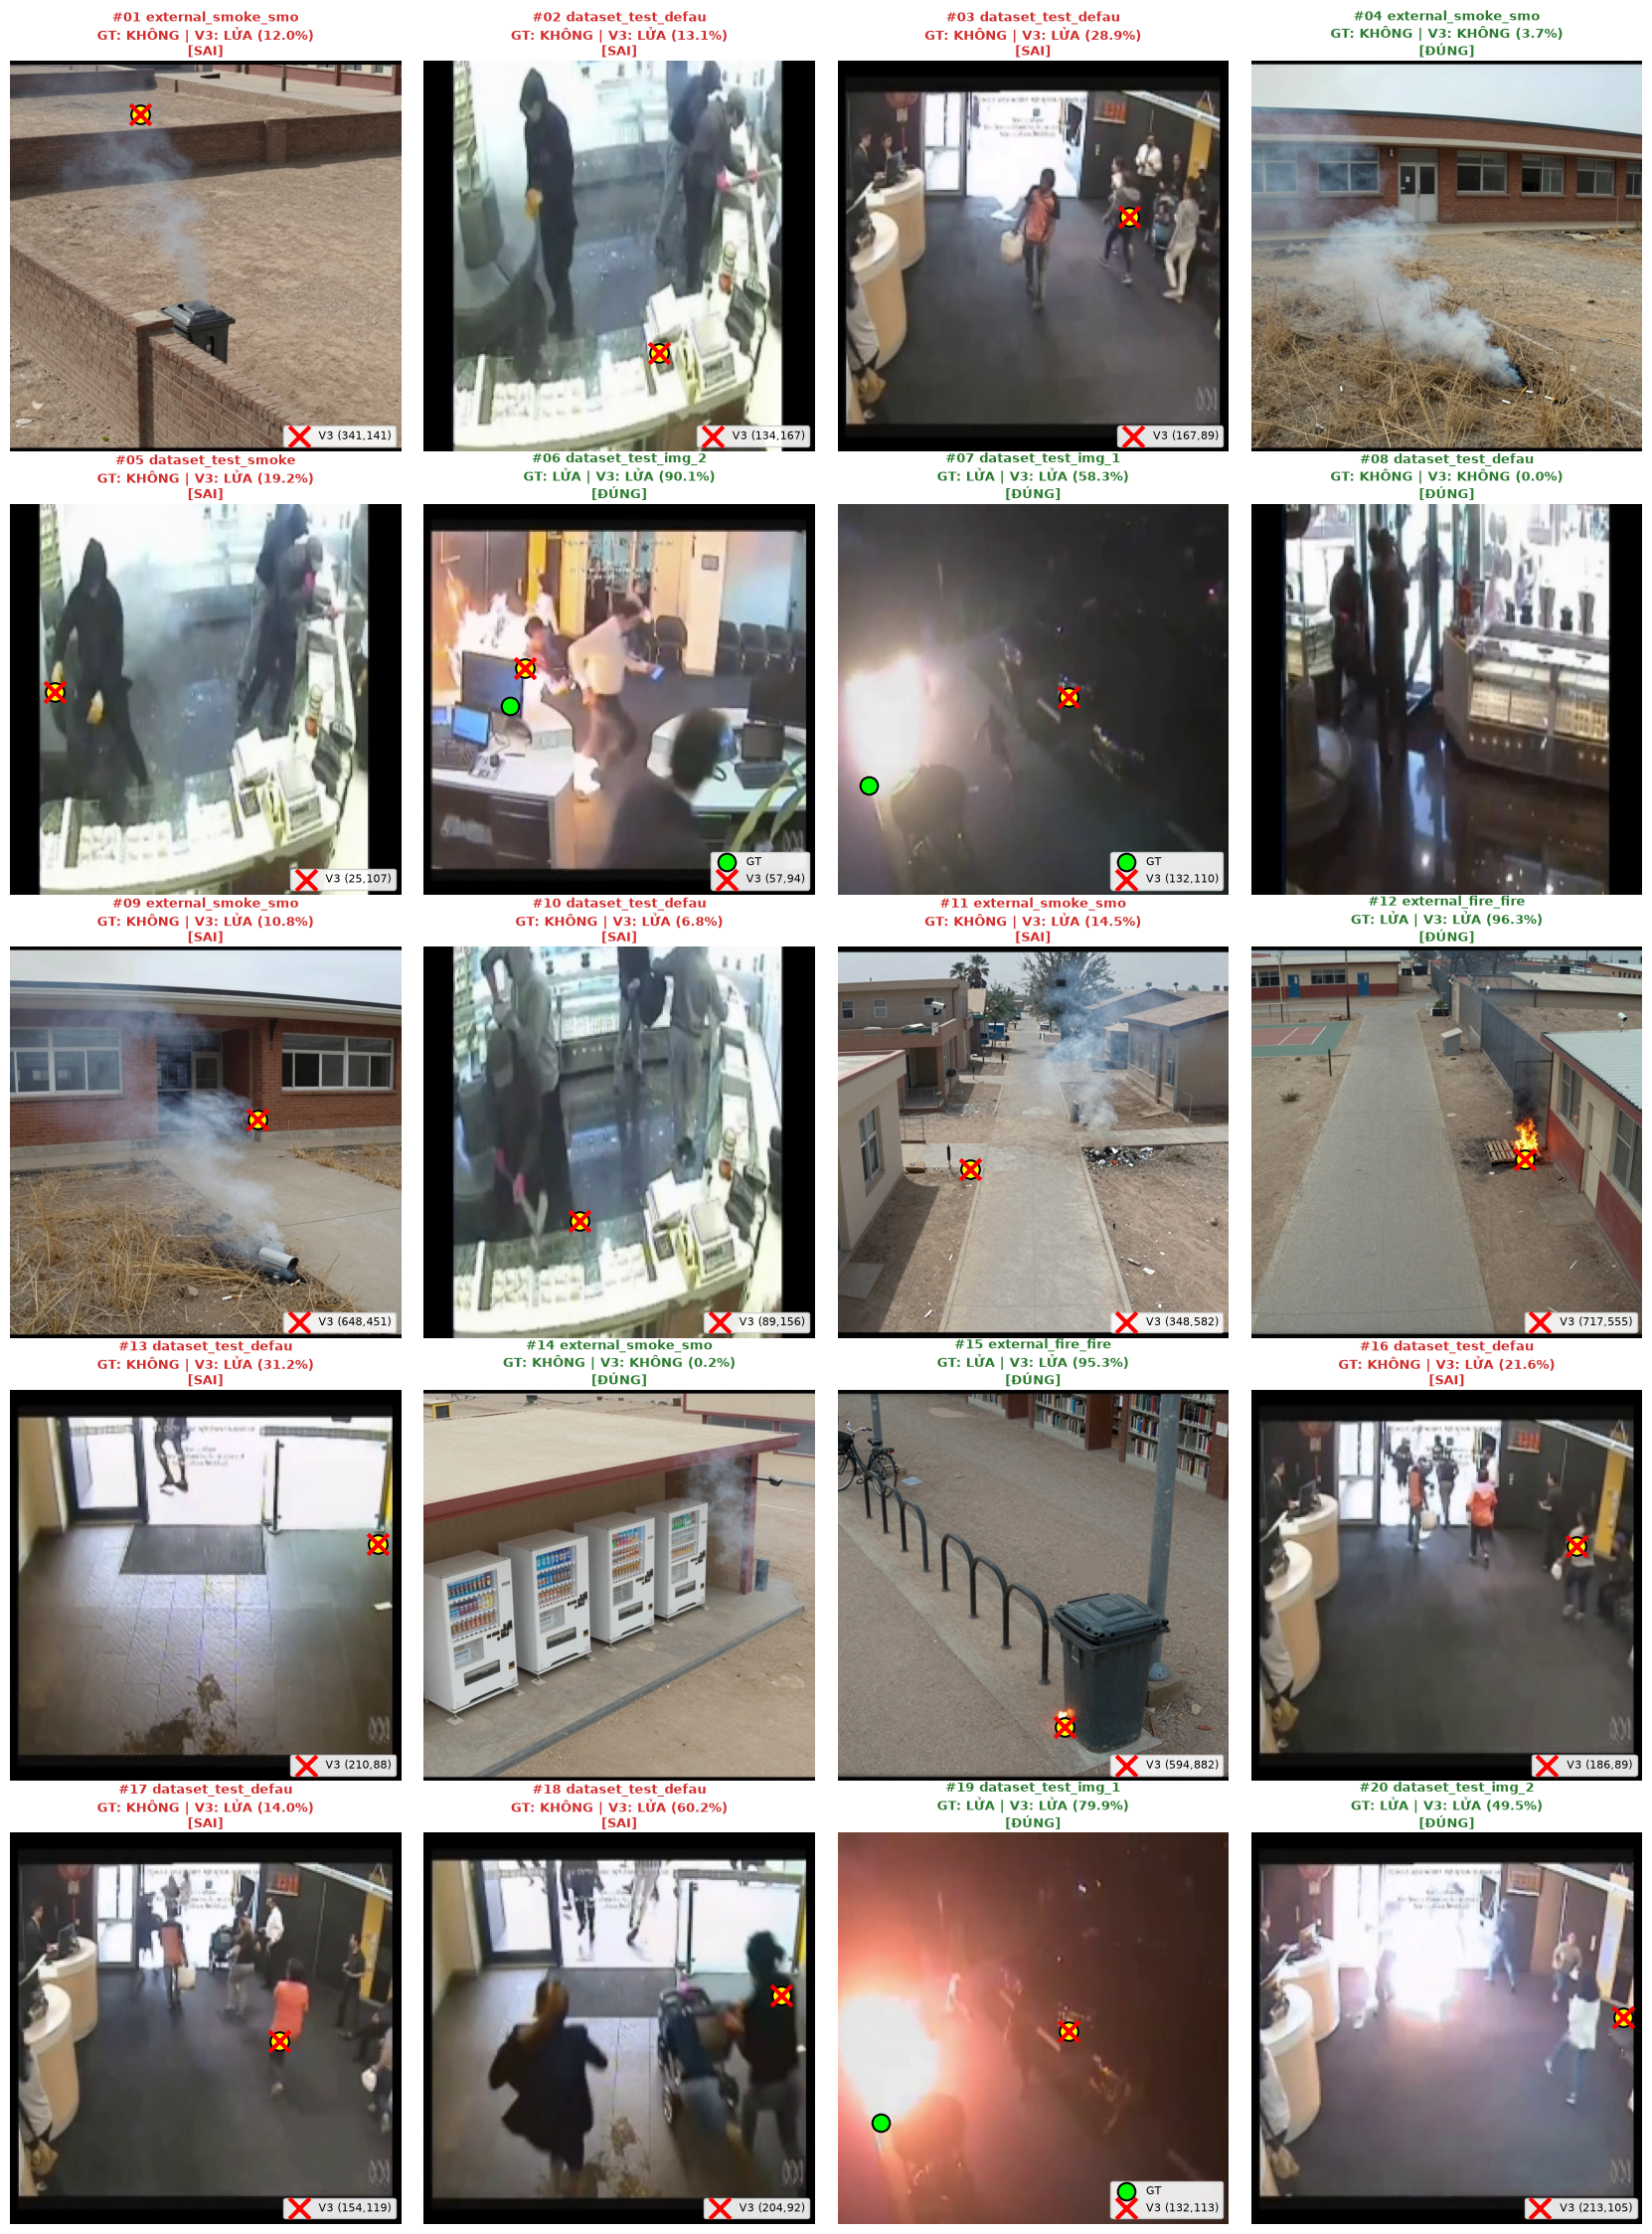

📸 Đã lưu ảnh preview: d:\2D Detection\FireGrounder-V3-main\FireGrounder-V3-main\v3_outputs\eval_fire_samples_preview.png


In [7]:
# Cell 7: Trực quan hóa Visual Preview 20 ảnh kiểm thử ngẫu nhiên
rng = random.Random(42)
sample_indices = rng.sample(range(len(dataset_records)), min(20, len(dataset_records)))

cols = 4
rows = (len(sample_indices) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 4.5))
axes = np.array(axes).flatten()

BEST_TH = 0.05

for i, s_idx in enumerate(sample_indices):
    ax = axes[i]
    rec = dataset_records[s_idx]
    img = Image.open(rec['path']).convert('RGB')
    w_orig, h_orig = img.size
    
    p_fire = preds_tensor[s_idx, 0].item()
    x_norm = preds_tensor[s_idx, 1].item()
    y_norm = preds_tensor[s_idx, 2].item()
    pred_is_fire = p_fire >= BEST_TH
    gt_is_fire = rec['has_fire'] == 1.0
    
    ax.imshow(img)
    
    # Vẽ Ground Truth nếu có
    if gt_is_fire and rec['coord_gt'] is not None:
        gt_x = rec['coord_gt'][0] * w_orig
        gt_y = rec['coord_gt'][1] * h_orig
        ax.scatter(gt_x, gt_y, c='lime', marker='o', s=160, edgecolors='black', linewidth=1.5, zorder=5, label='GT')
        
    # Vẽ Dự đoán V3
    if pred_is_fire:
        px = x_norm * w_orig
        py = y_norm * h_orig
        ax.scatter(px, py, c='yellow', marker='o', s=180, edgecolors='black', linewidth=1.5, zorder=6)
        ax.scatter(px, py, c='red', marker='x', s=220, linewidth=3.0, zorder=7, label=f'V3 ({px:.0f},{py:.0f})')
        ax.legend(loc='lower right', fontsize=8, facecolor='white', framealpha=0.9)
    
    # Tiêu đề với màu sắc phân biệt đúng/sai
    is_correct = (pred_is_fire == gt_is_fire)
    status_text = 'ĐÚNG' if is_correct else 'SAI'
    title_color = '#2E7D32' if is_correct else '#D32F2F'
    
    title = f"#{i+1:02d} {rec['file'][:18]}\nGT: {'LỬA' if gt_is_fire else 'KHÔNG'} | V3: {'LỬA' if pred_is_fire else 'KHÔNG'} ({p_fire*100:.1f}%)\n[{status_text}]"
    ax.set_title(title, fontsize=9, fontweight='bold', color=title_color, pad=4)
    ax.axis('off')

for j in range(len(sample_indices), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
out_preview = (NOTEBOOK_DIR / "previews" / "eval_fire_samples_preview.png") if (NOTEBOOK_DIR / "previews").exists() else (NOTEBOOK_DIR / "eval_fire_samples_preview.png")
out_preview.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_preview, dpi=130, bbox_inches='tight')
plt.show()
print(f'📸 Đã lưu ảnh preview: {out_preview}')